In [1]:
import os
print(os.getcwd())  # Prints current working directory


/home/jovyan/Project


In [2]:

print(os.listdir("/home/jovyan"))


['shared', 'scratch-drive', '.cache', '.local', '.ipython', '.jupyter', '.ipynb_checkpoints', 'Untitled Folder', 'Project', 'nltk_data', '.config', '.keras', '.nv', '.npm']


In [3]:
print(os.listdir("/home/jovyan/Project"))

['final.ipynb', '.ipynb_checkpoints', 'Combined Data.csv', 'fine_tuned_bert']


In [4]:
!pip install --upgrade setuptools
!pip install tensorflow
!pip install tensorflow-probability
!pip install transformers
!pip install datasets
!pip install numpy
!pip install pandas
!pip install scikit-learn
!pip install matplotlib seaborn
!pip install torch torchvision torchaudio 


In [5]:
import pandas as pd

# Specify the correct path
file_path = "/home/jovyan/Project/Combined Data.csv"

# Load the dataset
df = pd.read_csv(file_path)

# Display the first few rows
df.head()


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB
None


In [7]:
print("Number of duplicate rows before dropping:", df.duplicated().sum())

Number of duplicate rows before dropping: 0


In [8]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]


In [9]:
# Count rows where 'statement' or 'status' is null
null_rows = df[['statement', 'status']].isnull().any(axis=1).sum()
print(f"Number of rows with null values in 'statement' or 'status': {null_rows}")
df = df.dropna(subset=['statement', 'status'])
print(f"Number of rows in dataset: {len(df)}")

# Get the final shape of the dataframe
num_rows, num_columns = df.shape
print(f"Final dataset shape: {num_rows} rows, {num_columns} columns")


Number of rows with null values in 'statement' or 'status': 362
Number of rows in dataset: 52681
Final dataset shape: 52681 rows, 2 columns


In [10]:
df.head()

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


In [11]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK datasets if you haven't already
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize Lemmatizer and Stopwords list
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Function to clean the text
def clean_text(text):
    # Convert text to lowercase
    text = text.lower()
    # Remove special characters, punctuation, and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    # Remove stopwords
    text = ' '.join([word for word in text.split() if word not in stop_words])
    # Lemmatization (optional)
    text = ' '.join([lemmatizer.lemmatize(word) for word in text.split()])
    return text

# Apply the cleaning function to the 'statement' column
df['statement'] = df['statement'].apply(clean_text)

# Show the cleaned data
print(df['statement'].head())


[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/jovyan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


0                                              oh gosh
1    trouble sleeping confused mind restless heart ...
2    wrong back dear forward doubt stay restless re...
3    ive shifted focus something else im still worried
4                  im restless restless month boy mean
Name: statement, dtype: object


In [12]:
#data visulization

In [13]:
from collections import Counter

# Get word frequencies
all_words = ' '.join(df['statement']).split()
word_counts = Counter(all_words)
print(word_counts.most_common(10))  # Display the 10 most common words


[('like', 38566), ('feel', 35627), ('want', 28716), ('know', 24435), ('get', 23256), ('life', 23228), ('im', 21649), ('time', 21255), ('even', 18713), ('people', 16884)]


Count of each status:
status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64


/opt/conda/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


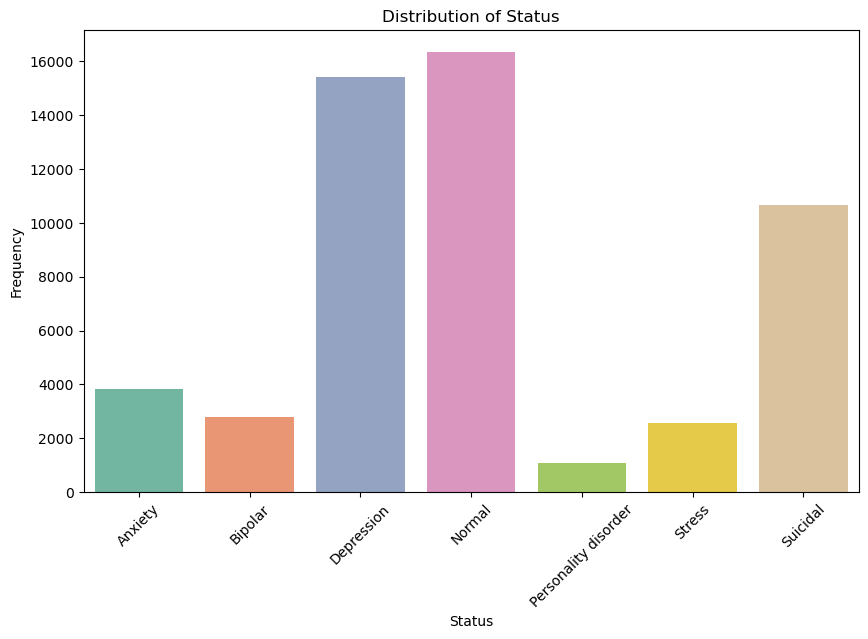

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'status' column to a categorical type
df['status'] = pd.Categorical(df['status'])

# Count the number of occurrences of each status
status_counts = df['status'].value_counts()
print("Count of each status:")
print(status_counts)

# Count plot for the 'status' column
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='status', palette='Set2')
plt.title('Distribution of Status')
plt.xlabel('Status')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()


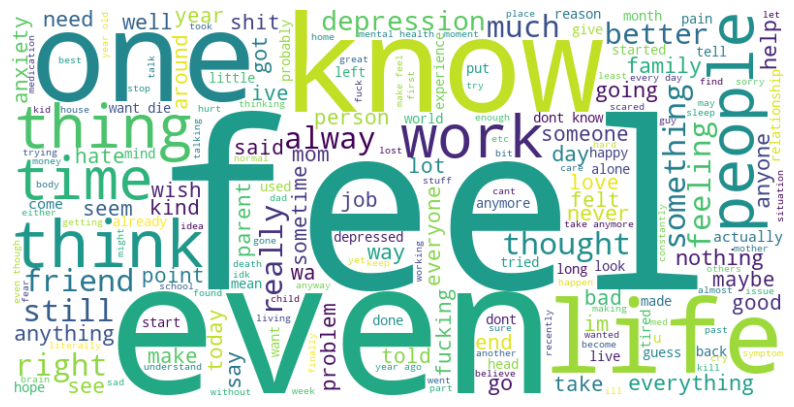

In [15]:
from wordcloud import WordCloud
#most frequent words 
# Generate a word cloud for the 'statement' column
text = ' '.join(df['statement'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Plot the word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


/opt/conda/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


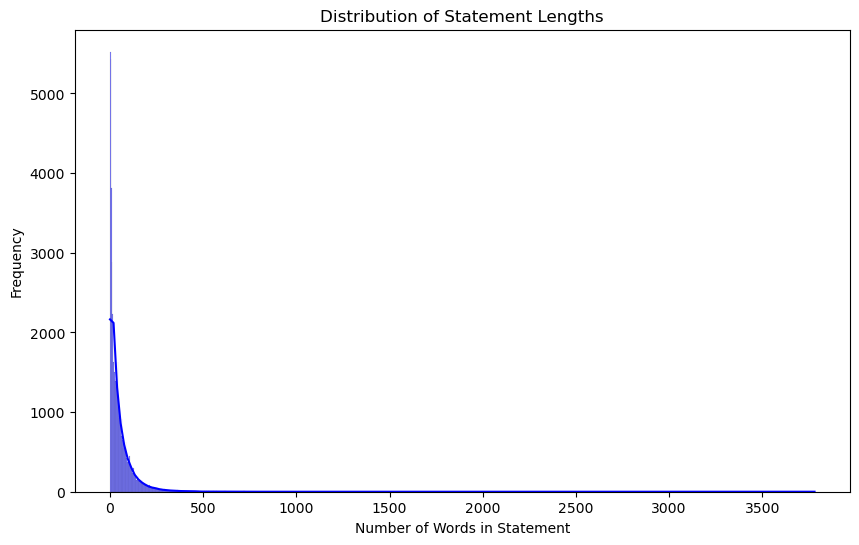

In [16]:
# Calculate the length of each statement (number of words)
df['statement_length'] = df['statement'].apply(lambda x: len(x.split()))

# Plot the distribution of statement lengths
plt.figure(figsize=(10, 6))
sns.histplot(df['statement_length'], kde=True, color='blue')
plt.title('Distribution of Statement Lengths')
plt.xlabel('Number of Words in Statement')
plt.ylabel('Frequency')
plt.show()


/opt/conda/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


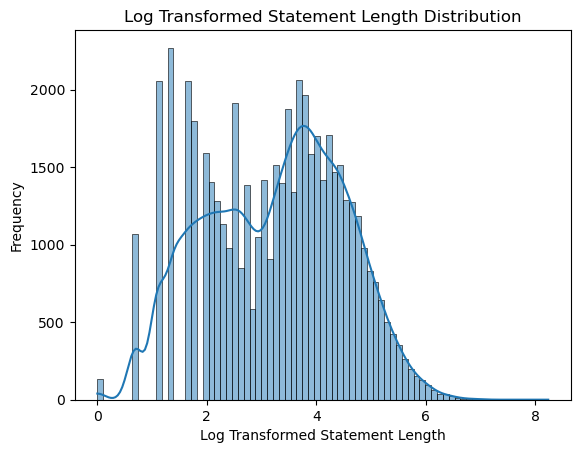

In [17]:
import numpy as np

# Apply log transformation to statement lengths
df['log_statement_length'] = df['statement_length'].apply(lambda x: np.log(x + 1))

# Optional: Check the distribution of transformed lengths
import matplotlib.pyplot as plt
sns.histplot(df['log_statement_length'], kde=True)
plt.title('Log Transformed Statement Length Distribution')
plt.xlabel('Log Transformed Statement Length')
plt.ylabel('Frequency')
plt.show()


In [18]:
from sklearn.preprocessing import LabelEncoder

# Label encode the 'status' column (target variable)
label_encoder = LabelEncoder()
df['status_encoded'] = label_encoder.fit_transform(df['status'])


In [19]:
df.head()

,statement,status,statement_length,log_statement_length,status_encoded
0,oh gosh,Anxiety,2,1.098612,0
1,trouble sleeping confused mind restless heart ...,Anxiety,7,2.079442,0
2,wrong back dear forward doubt stay restless re...,Anxiety,9,2.302585,0
3,ive shifted focus something else im still worried,Anxiety,8,2.197225,0
4,im restless restless month boy mean,Anxiety,6,1.945910,0


In [20]:
import torch
from transformers import BertTokenizer, BertModel

# Load BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

# Function to convert text to BERT embeddings
def get_bert_embedding(text):
    tokens = tokenizer(text, padding='max_length', truncation=True, max_length=50, return_tensors='pt')
    with torch.no_grad():
        output = model(**tokens)
    return output.last_hidden_state[:, 0, :].squeeze().numpy()  # CLS token representation

# Apply BERT to all statements
df['bert_embedding'] = df['statement'].apply(get_bert_embedding)


/opt/conda/lib/python3.11/site-packages/huggingface_hub/file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertModel: ['cls.seq_relationship.weight', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.decoder.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.dense.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you 

In [21]:
import numpy as np

X_features = np.stack(df['bert_embedding'].values)  # Convert embeddings to array
X_additional = df[['log_statement_length']].values  # Include additional numerical feature

# Final feature matrix
X = np.hstack((X_features, X_additional))  # Combine BERT embeddings and log length

# Target labels
y = df['status_encoded'].values


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train logistic regression model
clf = LogisticRegression(max_iter=500)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

# Evaluate model
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.696403150801936
              precision    recall  f1-score   support

           0       0.68      0.65      0.66       755
           1       0.62      0.57      0.60       527
           2       0.62      0.68      0.65      3016
           3       0.86      0.91      0.89      3308
           4       0.49      0.32      0.39       237
           5       0.49      0.42      0.45       536
           6       0.61      0.54      0.58      2158

    accuracy                           0.70     10537
   macro avg       0.63      0.58      0.60     10537
weighted avg       0.69      0.70      0.69     10537



/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [23]:
!pip install torch torchvision torchaudio

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from transformers import BertTokenizer, BertModel, BertForSequenceClassification
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)




Using device: cuda


In [25]:
# Load pre-trained BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(df['statement'], df['status_encoded'], test_size=0.2, random_state=42)

# Define PyTorch Dataset class
class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoded = tokenizer(self.texts[idx], padding='max_length', truncation=True, max_length=50, return_tensors='pt')
        return {key: val.squeeze(0) for key, val in encoded.items()}, torch.tensor(self.labels[idx])

# Create DataLoaders
train_dataset = TextDataset(X_train.tolist(), y_train.tolist())
test_dataset = TextDataset(X_test.tolist(), y_test.tolist())

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Load BERT model for classification
bert_model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=len(df['status'].unique()))
bert_model.to(device)

# Set up optimizer and loss function
optimizer = optim.AdamW(bert_model.parameters(), lr=2e-5)
loss_fn = nn.CrossEntropyLoss()


/opt/conda/lib/python3.11/site-packages/huggingface_hub/file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForSequenceClassification: ['cls.seq_relationship.weight', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.decoder.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.dense.bias']
- This IS expected if you are initializing BertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForSeq

In [26]:

# Fine-Tune BERT Model
epochs = 3
for epoch in range(epochs):
    bert_model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        inputs, labels = batch
        inputs = {key: val.to(device) for key, val in inputs.items()}
        labels = labels.to(device)

        outputs = bert_model(**inputs)
        loss = loss_fn(outputs.logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

# Save Fine-Tuned BERT Model
bert_model.save_pretrained("fine_tuned_bert")
tokenizer.save_pretrained("fine_tuned_bert")

# Evaluate Fine-Tuned BERT Model
bert_model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for batch in test_loader:
        inputs, labels = batch
        inputs = {key: val.to(device) for key, val in inputs.items()}
        labels = labels.to(device)

        outputs = bert_model(**inputs)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Print BERT Model Results
print("\nFine-Tuned BERT Model Performance:")
print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred))



Epoch 1, Loss: 1889.9545
Epoch 2, Loss: 1302.1780
Epoch 3, Loss: 967.4432

Fine-Tuned BERT Model Performance:
Accuracy: 0.7907374015374395
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       755
           1       0.90      0.81      0.85       527
           2       0.77      0.65      0.71      3016
           3       0.92      0.94      0.93      3308
           4       0.76      0.68      0.72       237
           5       0.63      0.72      0.68       536
           6       0.65      0.74      0.69      2158

    accuracy                           0.79     10537
   macro avg       0.78      0.78      0.77     10537
weighted avg       0.79      0.79      0.79     10537



In [27]:
from transformers import BertModel, BertTokenizer
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, classification_report

# ---- LSTM MODEL USING BERT EMBEDDINGS ----
class BERT_LSTM(nn.Module):
    def __init__(self, bert_model, hidden_dim, num_classes):
        super(BERT_LSTM, self).__init__()
        self.bert = bert_model  # Use the fine-tuned BERT model
        self.lstm = nn.LSTM(input_size=768, hidden_size=hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids, attention_mask):
        # Get output from BERT
        bert_output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        
        # Get embeddings from the first element of the output tuple (bert_output[0])
        embeddings = bert_output[0]  # This should be (batch_size, seq_length, 768)
        
        # Check shape of the embeddings
        #print(f"Embeddings shape: {embeddings.shape}")
        
        # Ensure embeddings are the correct shape
        assert embeddings.size(-1) == 768, f"Expected embedding size of 768, got {embeddings.size(-1)}"
        
        # Pass embeddings to the LSTM
        lstm_out, _ = self.lstm(embeddings)  # Shape: (batch_size, seq_length, hidden_dim*2)
        output = self.fc(lstm_out[:, -1, :])  # Use last LSTM output for classification
        return output


# Initialize BERT-LSTM Model
hidden_dim = 256
num_classes = len(df['status'].unique())  # Assuming you have your dataframe df with 'status' column
bert_model = BertModel.from_pretrained('bert-base-uncased')  # Use BertModel for embeddings
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Initialize the model
bert_lstm_model = BERT_LSTM(bert_model, hidden_dim, num_classes).to(device)

# Set up optimizer and loss function for LSTM
optimizer = optim.AdamW(bert_lstm_model.parameters(), lr=2e-5)
loss_fn = nn.CrossEntropyLoss()

# Train LSTM on BERT Embeddings
epochs = 3
for epoch in range(epochs):
    bert_lstm_model.train()
    total_loss = 0
    for batch in train_loader:  # Assuming you have a DataLoader for training
        optimizer.zero_grad()
        inputs, labels = batch
        inputs = {key: val.to(device) for key, val in inputs.items()}
        labels = labels.to(device)

        outputs = bert_lstm_model(inputs["input_ids"], inputs["attention_mask"])
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"\nEpoch {epoch+1} (LSTM), Loss: {total_loss:.4f}")

# Evaluate LSTM Model
bert_lstm_model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for batch in test_loader:  # Assuming you have a DataLoader for testing
        inputs, labels = batch
        inputs = {key: val.to(device) for key, val in inputs.items()}
        labels = labels.to(device)

        outputs = bert_lstm_model(inputs["input_ids"], inputs["attention_mask"])
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Print LSTM Model Results
print("\nBERT + LSTM Model Performance:")
print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred))


/opt/conda/lib/python3.11/site-packages/huggingface_hub/file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertModel: ['cls.seq_relationship.weight', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.decoder.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.dense.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you 


Epoch 1 (LSTM), Loss: 1872.6085

Epoch 2 (LSTM), Loss: 1321.4005

Epoch 3 (LSTM), Loss: 1008.5549

BERT + LSTM Model Performance:
Accuracy: 0.7851380848438835
              precision    recall  f1-score   support

           0       0.87      0.81      0.84       755
           1       0.80      0.84      0.82       527
           2       0.67      0.82      0.74      3016
           3       0.94      0.93      0.93      3308
           4       0.75      0.63      0.69       237
           5       0.69      0.66      0.68       536
           6       0.73      0.55      0.63      2158

    accuracy                           0.79     10537
   macro avg       0.78      0.75      0.76     10537
weighted avg       0.79      0.79      0.78     10537



In [28]:
df.head()

,statement,status,statement_length,log_statement_length,status_encoded,bert_embedding
0,oh gosh,Anxiety,2,1.098612,0,"[-0.03352886, 0.25487745, 0.017096031, -0.1495..."
1,trouble sleeping confused mind restless heart ...,Anxiety,7,2.079442,0,"[-0.069391094, 0.09632786, -0.10716323, -0.269..."
2,wrong back dear forward doubt stay restless re...,Anxiety,9,2.302585,0,"[-0.27361703, -0.032437038, -0.023035295, -0.2..."
3,ive shifted focus something else im still worried,Anxiety,8,2.197225,0,"[-0.17934261, 0.41133657, 0.13647582, -0.22080..."
4,im restless restless month boy mean,Anxiety,6,1.945910,0,"[-0.11079461, 0.21627824, 0.16875596, -0.13728..."


In [29]:
labels = df['status_encoded'].values
print(labels)

[0 0 0 ... 0 0 0]


In [ ]:
import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.preprocessing import LabelEncoder
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

# Assuming your DataFrame is called `df`
# Apply label encoding to the 'status' column if it's not already encoded
label_encoder = LabelEncoder()
df['status_encoded'] = label_encoder.fit_transform(df['status'])

# Prepare the input (BERT embeddings) and output (status_encoded)
X = np.array(df['bert_embedding'].tolist())  # Convert BERT embeddings from string to array
y = df['status_encoded'].values

# Compute class weights (Inverse of class frequencies)
class_counts = pd.Series(y).value_counts().sort_index()
class_weights = 1. / class_counts.values
weights = np.array([class_weights[label] for label in y])

# Convert to PyTorch tensor
weights = torch.tensor(weights, dtype=torch.float)

# Check dataset length and weights length
print(f"Dataset Length: {len(X)}")
print(f"Weights Length: {len(weights)}")

# Ensure that the weights array is the same size as the dataset
assert len(weights) == len(X), "Mismatch between weights and dataset length."

# Create WeightedRandomSampler
sampler = WeightedRandomSampler(weights, len(weights), replacement=True)

# Create custom dataset class
class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # Log the idx to see if there's an out-of-bounds issue
        if idx >= len(self.X):
            print(f"Error: Attempted to access index {idx} which is out of bounds.")
            raise IndexError(f"Index {idx} is out of bounds.")
        x = torch.tensor(self.X[idx], dtype=torch.float32)
        y = torch.tensor(self.y[idx], dtype=torch.long)
        return x, y

# Split dataset into train and test
train_size = int(0.8 * len(df))
train_X, train_y = X[:train_size], y[:train_size]
test_X, test_y = X[train_size:], y[train_size:]

train_dataset = SentimentDataset(train_X, train_y)
test_dataset = SentimentDataset(test_X, test_y)
print(f"Training dataset length: {len(train_dataset)}")
print(f"Testing dataset length: {len(test_dataset)}")

def collate_fn(batch):
    inputs, labels = zip(*batch)
    lengths = torch.tensor([len(x) for x in inputs], dtype=torch.long)
    # Convert list of tensors into a padded tensor
    inputs = pad_sequence(inputs, batch_first=True, padding_value=0)  # Shape: (batch_size, seq_length, input_dim)
    labels = torch.stack(labels)  # Stack instead of using torch.tensor()
    return inputs, labels, lengths
    
# Create DataLoader with drop_last=True to avoid incomplete batches
train_loader = DataLoader(train_dataset, batch_size=16, drop_last=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, collate_fn=collate_fn)





class BertLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=1):
        super(BertLSTM, self).__init__()
        
        # LSTM layer
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.2)
        
        # Fully connected layer for output
        self.fc = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x, lengths):
        x = x.unsqueeze(1)
        print(f"Input shape before packing: {x.shape}")
        lengths = lengths.cpu()
        # Pack the padded sequences
        packed_input = pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        # Pass through LSTM
        packed_out, (h_n, c_n) = self.lstm(packed_input)
        # Get the last hidden state for classification
        lstm_out, _ = pad_packed_sequence(packed_out, batch_first=True)
        lstm_out = h_n[-1]
        # Output layer
        out = self.fc(lstm_out)
        return out

# Hyperparameters
input_dim = 768  # BERT output dimension (Assuming you're using bert-base-uncased)
hidden_dim = 128  # LSTM hidden state dimension
output_dim = len(class_counts)  # Number of unique classes (statuses)

# Instantiate the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BertLSTM(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim)
model = model.to(device)

# Define loss and optimizer
criterion = nn.CrossEntropyLoss(weight=weights.to(device))  # Use weighted loss
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train the model
epochs = 5
for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch in train_loader:
        inputs, labels, lengths = batch
        inputs, labels, lengths = inputs.to(device), labels.to(device), lengths.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs, lengths)
        
        # Calculate loss
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        # Calculate accuracy
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    
    epoch_loss = total_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")

# Evaluate the model
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for batch in test_loader:
        inputs, labels, lengths = batch
        inputs, labels, lengths = inputs.to(device), labels.to(device), lengths.to(device)
        
        
        outputs = model(inputs, lengths)
        _, predicted = torch.max(outputs, 1)
        
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")


Dataset Length: 52681
Weights Length: 52681
Training dataset length: 42144
Testing dataset length: 10537
Input shape before packing: torch.Size([16, 1, 768])


/opt/conda/lib/python3.11/site-packages/torch/nn/modules/rnn.py:71: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "
